# Imports

In [2]:
import numpy as np
import sympy as sp
from numba import njit

Mis funciones definidas en `/code/src/`

In [ ]:
import sys
import os

# Navigate up to the 'code' directory, then into 'src'
sys.path.append(os.path.abspath('../src'))

# Import the functions
from dynamics import generate_orbit, generate_escape_time_fractal, generate_fatou_basins, generate_fatou_basins_and_times, make_generate_orbit_jitted, make_generate_escape_time_fractal_jitted, make_generate_fatou_basins_jitted, make_generate_fatou_basins_and_times_jitted
from utils import DynamicsPlotter

# Default settings

In [3]:
horizontal_pixels = 10000
vertical_pixels = 10000

max_iter = 1e3

tolerance = 1e-6
infinity_threshold = 1e10

julia_thickness = max(1, int(horizontal_pixels/2000))

# Chapter 6: Periodic Points

## Julia set of $z \mapsto z^2 - z$

In [4]:
modified_max_iter = 128

modified_infinity_threshold=2.0

In [5]:
@njit
def Rz2mz(z):
    return z**2 - z

generate_escape_time_fractal_jitted_Rz2mz = make_generate_escape_time_fractal_jitted(Rz2mz)

In [6]:
center = 0.5
max_distance_to_center = 1.55

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

In [7]:
escape_times = generate_escape_time_fractal_jitted_Rz2mz(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, max_iter=modified_max_iter, infinity_threshold=modified_infinity_threshold)

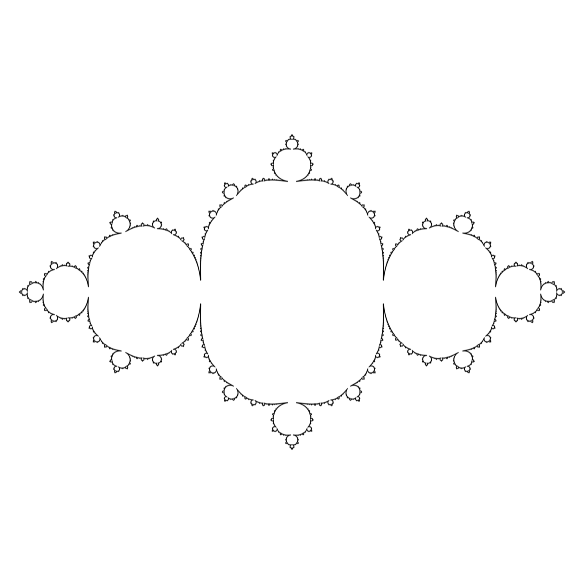

In [ ]:
plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)
fig, ax = plotter.plot_julia_set_from_escape_times(escape_times, max_iter=modified_max_iter, thickness=julia_thickness+3, title="", show_axis=False)

In [11]:
plotter.save_figure(fig, "../../figures/z_squared_minus_z_julia_set.pdf")

Saved figure to: ../../figures/z_squared_minus_z_julia_set.pdf


In [12]:
center = 0.5
max_distance_to_center = 1.55

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center+0.6
ymax = center.imag+max_distance_to_center-0.6

In [13]:
escape_times = generate_escape_time_fractal_jitted_Rz2mz(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, max_iter=modified_max_iter, infinity_threshold=modified_infinity_threshold)

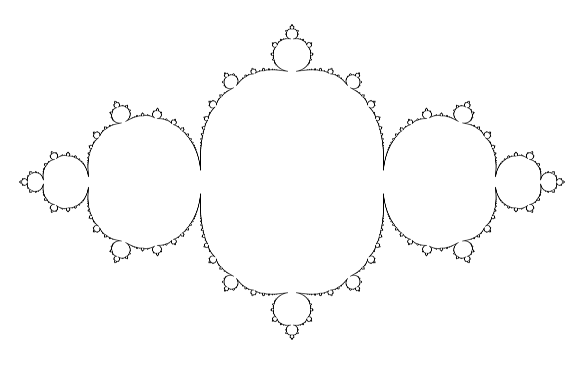

In [14]:
plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)
fig, ax = plotter.plot_julia_set_from_escape_times(escape_times, max_iter=modified_max_iter, thickness=julia_thickness+3, title="", show_axis=False)

In [15]:
plotter.save_figure(fig, "../../figures/z_squared_minus_z_julia_set-thin.pdf")

Saved figure to: ../../figures/z_squared_minus_z_julia_set-thin.pdf


## Rationally indifferent points

Sectors plot saved successfully.


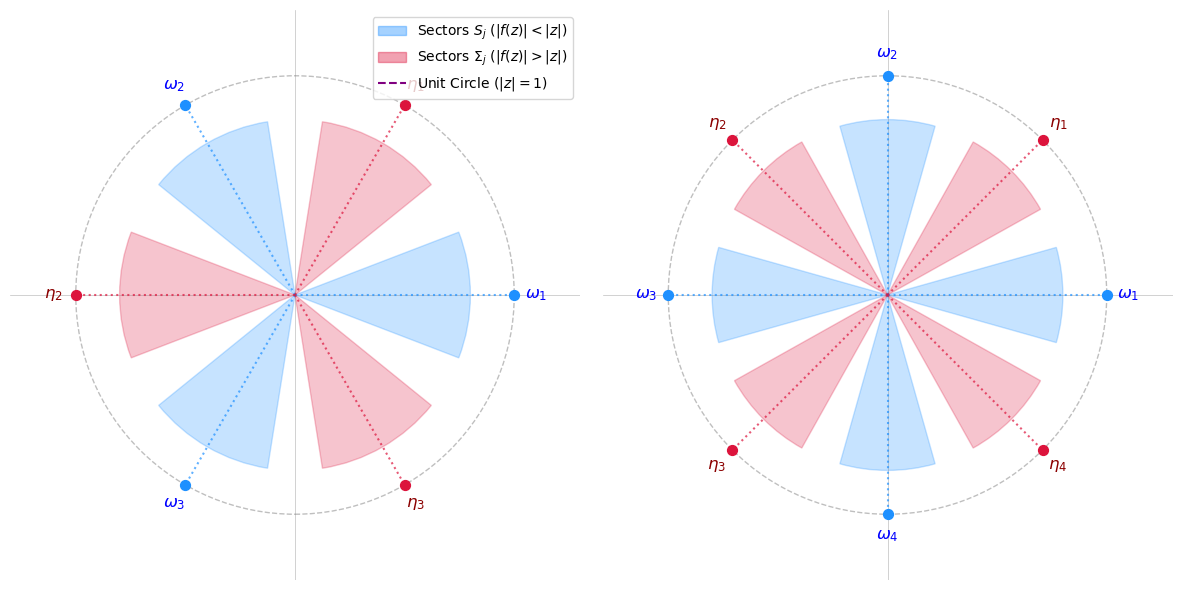

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D

# Let's create a beautiful plot showing the sectors centered at the origin
# for n = 3 and n = 4, with r_0 < 1 and \theta_0 < \pi/(2n).

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
ps = [3, 4]
r_0 = 0.8  # chosen r_0 < 1
theta_0_factor = 0.7

for idx, p in enumerate(ps):
    ax = axs[idx]
    
    # Unit circle for reference
    unit_circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', alpha=0.5, label='Unit Circle ($|z|=1$)')
    ax.add_artist(unit_circle)
    
    # Boundary of the sectors circle (r_0)
    # r0_circle = plt.Circle((0, 0), r_0, color='purple', fill=False, linestyle='--', linewidth=0.5, label=f'Boundary $|z| = r_0$')
    # ax.add_artist(r0_circle)
    
    # Axes
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
    
    # Define \theta_0 < \pi / (2p)
    theta_max = np.pi / (2 * p)
    theta_0 = theta_0_factor * theta_max  # strict inequality \theta_0 < \pi/(2p)
    
    # Roots of 1 (blue dots on unit circle)
    j_1 = np.arange(p)
    angles_1 = 2 * np.pi * j_1 / p
    ax.scatter(np.cos(angles_1), np.sin(angles_1), color='dodgerblue', s=50, zorder=5)

    for j, phi in enumerate(angles_1):
        # Wedge arguments: center, radius, theta1 (degrees), theta2 (degrees)
        theta1_deg = np.degrees(phi - theta_0)
        theta2_deg = np.degrees(phi + theta_0)
        
        # Shade the sector
        wedge = patches.Wedge((0, 0), r_0, theta1_deg, theta2_deg, 
                              facecolor='dodgerblue', alpha=0.25, edgecolor='dodgerblue', linewidth=1)
        ax.add_patch(wedge)
        
        # Draw the central ray
        ax.plot([0, 1 * np.cos(phi)], [0, 1 * np.sin(phi)], color='dodgerblue', linestyle=':', alpha=0.7)

        # Label ray outside r_0
        ax.text(1.1 * np.cos(phi), 1.1 * np.sin(phi), f'$\omega_{j+1}$', 
                    color='blue', fontsize=12, ha='center', va='center')
    
    # Roots of -1 (red dots on unit circle)
    angles_minus1 = (np.pi + 2 * np.pi * j_1) / p
    ax.scatter(np.cos(angles_minus1), np.sin(angles_minus1), color='crimson', s=50, zorder=5)
    
    # Draw sectors around the rays of roots of -1
    for j, phi in enumerate(angles_minus1):
        # Wedge arguments: center, radius, theta1 (degrees), theta2 (degrees)
        theta1_deg = np.degrees(phi - theta_0)
        theta2_deg = np.degrees(phi + theta_0)
        
        # Shade the sector
        wedge = patches.Wedge((0, 0), r_0, theta1_deg, theta2_deg, 
                              facecolor='crimson', alpha=0.25, edgecolor='crimson', linewidth=1)
        ax.add_patch(wedge)
        
        # Draw the central ray
        ax.plot([0, 1 * np.cos(phi)], [0, 1 * np.sin(phi)], color='crimson', linestyle=':', alpha=0.7)

        # Label ray outside r_0
        ax.text(1.1 * np.cos(phi), 1.1 * np.sin(phi), f'$\eta_{j+1}$', 
            color='darkred', fontsize=12, ha='center', va='center')
        
    # ax.set_title(f"Sectors $S_j$ and $\Sigma_j$ for rationally indifferent fixed point", fontsize=14, pad=10)
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect('equal', 'box')
    ax.grid(True, which='both', linestyle=':', linewidth=0.5, alpha=0.5)
    ax.axis('off')  # cleaner look without box ticks
    
    if idx == 0:
        legend_elements = [
            patches.Patch(facecolor='dodgerblue', alpha=0.4, edgecolor='dodgerblue', label=f'Sectors $S_j$ ($|f(z)| < |z|$)'),
            patches.Patch(facecolor='crimson', alpha=0.4, edgecolor='crimson', label=f'Sectors $\Sigma_j$ ($|f(z)| > |z|$)'),
            Line2D([0], [0], color='gray', linestyle='--', label='Unit Circle ($|z|=1$)')#,
            # Line2D([0], [0], color='purple', linestyle='--', label='Boundary $|z| = r_0$')
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
# plt.savefig('../../figures/sectors_lemma_visualization.pdf')
# print("Sectors plot saved successfully.")